In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uroojazizkhan/food-delivery/food_delivery_dataset.csv


# A. Load & Understand

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
 

In [3]:
df = pd.read_csv("/kaggle/input/datasets/uroojazizkhan/food-delivery/food_delivery_dataset.csv")


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 38964
Number of columns: 22


In [5]:
print("\nColumn names:\n", df.columns.tolist())


Column names:
 ['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)', 'distance_km', 'delivery_speed']


In [6]:
print("\nData types:\n", df.dtypes)


Data types:
 ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
distance_km                    float64
delivery_speed                  object
dtype: object


In [7]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 ID                                0
Delivery_person_ID                0
Delivery_person_Age            1019
Delivery_person_Ratings        1055
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                     835
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
distance_km                       0
delivery_speed                    0
dtype: int64


In [8]:
print("\nTotal duplicate rows:", df.duplicated().sum())


Total duplicate rows: 0


In [9]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38964 entries, 0 to 38963
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           38964 non-null  object 
 1   Delivery_person_ID           38964 non-null  object 
 2   Delivery_person_Age          37945 non-null  float64
 3   Delivery_person_Ratings      37909 non-null  float64
 4   Restaurant_latitude          38964 non-null  float64
 5   Restaurant_longitude         38964 non-null  float64
 6   Delivery_location_latitude   38964 non-null  float64
 7   Delivery_location_longitude  38964 non-null  float64
 8   Order_Date                   38964 non-null  object 
 9   Time_Orderd                  38129 non-null  object 
 10  Time_Order_picked            38964 non-null  object 
 11  Weather_conditions           38964 non-null  object 
 12  Road_traffic_density         38964 non-null  object 
 13  Vehicle_conditio

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [10]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (38964, 22)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


# B. Clean the Data

In [11]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

In [12]:
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())

In [13]:
df = df.dropna(subset=["Time_Orderd"])

In [14]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y") 
df["Order_Day"] = df["Order_Date"].dt.day_name()
df["Order_Month"] = df["Order_Date"].dt.month_name()

In [15]:
print("Duplicates found:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates found: 0


In [16]:
print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nFinal shape:", df.shape)


Missing values after cleaning:
 ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
distance_km                    0
delivery_speed                 0
Order_Day                      0
Order_Month                    0
dtype: int64

Final shape: (38964, 24)


In [17]:
df.to_csv("cleaned_food_delivery_dataset.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_food_delivery_dataset.csv'")


Cleaned dataset saved as 'cleaned_food_delivery_dataset.csv'


# C. Basic Analysis

In [18]:
total_deliveries = len(df)
print("Total deliveries:", total_deliveries)

Total deliveries: 38964


In [19]:
avg_time = df["Time_taken (min)"].mean()
min_time = df["Time_taken (min)"].min()
max_time = df["Time_taken (min)"].max()
print("\nAverage delivery time (min):", round(avg_time, 2))
print("Minimum delivery time (min):", min_time)
print("Maximum delivery time (min):", max_time)


Average delivery time (min): 26.58
Minimum delivery time (min): 10
Maximum delivery time (min): 54


In [20]:
avg_distance = df["distance_km"].mean()
speed_counts = df["delivery_speed"].value_counts()
print("\nAverage delivery distance (km):", round(avg_distance, 2))
print("Delivery speed breakdown:\n", speed_counts)


Average delivery distance (km): 9.77
Delivery speed breakdown:
 delivery_speed
Average    19982
Fast       10164
Slow        8818
Name: count, dtype: int64


In [21]:
avg_rating = df["Delivery_person_Ratings"].mean()
avg_age = df["Delivery_person_Age"].mean()
print("\nAverage delivery-person rating:", round(avg_rating, 2))
print("Average delivery-person age:", round(avg_age, 1))


Average delivery-person rating: 4.63
Average delivery-person age: 29.6


# D. Answer the 3 Competition Questions

## Q1 – Traffic Impact: Which road traffic condition has the highest average delivery time?  

In [22]:
import os
os.makedirs("outputs", exist_ok=True)

In [23]:
traffic_time = df.groupby("Road_traffic_density")["Time_taken (min)"].mean().sort_values(ascending=False)
print("Q1 - Average delivery time by traffic condition:\n", traffic_time)
print(f"\nAnswer: '{traffic_time.idxmax()}' traffic has the highest average delivery time "
      f"({traffic_time.max():.2f} min).")

Q1 - Average delivery time by traffic condition:
 Road_traffic_density
Jam       31.440229
High      27.413489
Medium    26.925701
Low       21.496461
Name: Time_taken (min), dtype: float64

Answer: 'Jam' traffic has the highest average delivery time (31.44 min).


## Q2 – Distance Impact: How does delivery distance affect delivery time? Support your conclusion with data.
 

In [24]:
correlation = df["distance_km"].corr(df["Time_taken (min)"])
print(f"Q2 - Correlation between distance and delivery time: {correlation:.2f}")

bins = [0, 5, 10, 15, 20, 25]
labels = ["0-5 km", "5-10 km", "10-15 km", "15-20 km", "20-25 km"]
df["distance_bucket"] = pd.cut(df["distance_km"], bins=bins, labels=labels)
distance_trend = df.groupby("distance_bucket", observed=True)["Time_taken (min)"].mean()
print("\nAverage delivery time by distance range:\n", distance_trend)

print("\nAnswer:")
print(f"There is a positive correlation ({correlation:.2f}) between distance and delivery time — "
      f"meaning delivery time generally increases as distance increases.")
print(f"Deliveries under 5 km take an average of {distance_trend.iloc[0]:.1f} min, "
      f"while deliveries of 20-25 km take {distance_trend.iloc[-1]:.1f} min — "
      f"a clear increase of about {distance_trend.iloc[-1] - distance_trend.iloc[0]:.1f} minutes.")
print("However, the increase slows down after 10-15 km, suggesting distance matters most for shorter routes, "
      "and other factors (traffic, weather) dominate for longer ones.")

Q2 - Correlation between distance and delivery time: 0.32

Average delivery time by distance range:
 distance_bucket
0-5 km      22.420308
5-10 km     24.639349
10-15 km    30.091511
15-20 km    30.074647
20-25 km    30.083879
Name: Time_taken (min), dtype: float64

Answer:
There is a positive correlation (0.32) between distance and delivery time — meaning delivery time generally increases as distance increases.
Deliveries under 5 km take an average of 22.4 min, while deliveries of 20-25 km take 30.1 min — a clear increase of about 7.7 minutes.
However, the increase slows down after 10-15 km, suggesting distance matters most for shorter routes, and other factors (traffic, weather) dominate for longer ones.


## Q3 – Combined Conditions: Which combination of weather condition and traffic density has the highest average delivery time?  

In [25]:
combo_time = df.groupby(["Weather_conditions", "Road_traffic_density"])["Time_taken (min)"].mean()
combo_time = combo_time.sort_values(ascending=False)
print("\nQ3 - Top 5 weather + traffic combinations by avg delivery time:\n", combo_time.head(5))
print(f"\nAnswer: '{combo_time.index[0][0]}' weather with '{combo_time.index[0][1]}' traffic "
      f"has the highest average delivery time ({combo_time.iloc[0]:.2f} min).")


Q3 - Top 5 weather + traffic combinations by avg delivery time:
 Weather_conditions  Road_traffic_density
Fog                 Jam                     36.889454
Cloudy              Jam                     36.708173
Windy               Jam                     30.396925
Sandstorms          Jam                     30.248687
Stormy              Jam                     30.197835
Name: Time_taken (min), dtype: float64

Answer: 'Fog' weather with 'Jam' traffic has the highest average delivery time (36.89 min).


## E. Create Visualizations Wiith Plotty Charts

In [26]:
import os
os.makedirs("outputs", exist_ok=True)

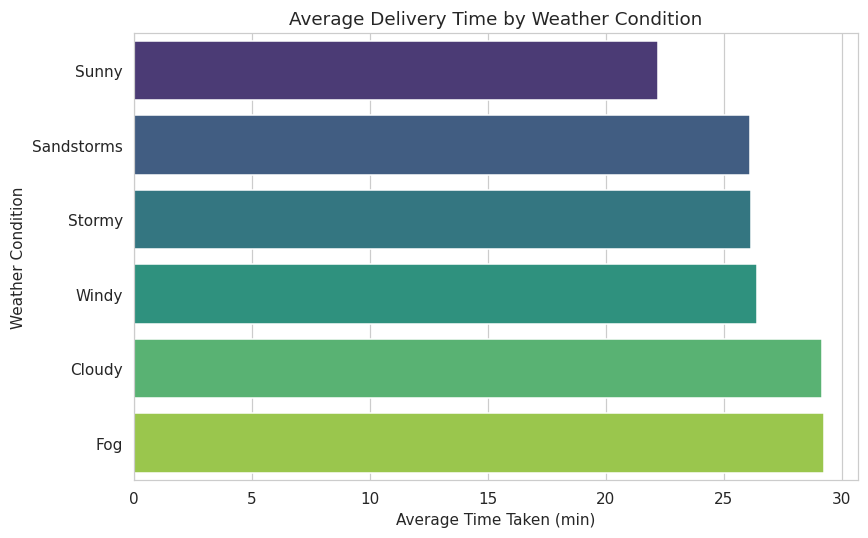

In [27]:
 weather_time = df.groupby("Weather_conditions")["Time_taken (min)"].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=weather_time.values, y=weather_time.index, hue=weather_time.index,
            palette="viridis", legend=False)
plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Average Time Taken (min)")
plt.ylabel("Weather Condition")
plt.tight_layout()
plt.savefig("outputs/1_weather_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

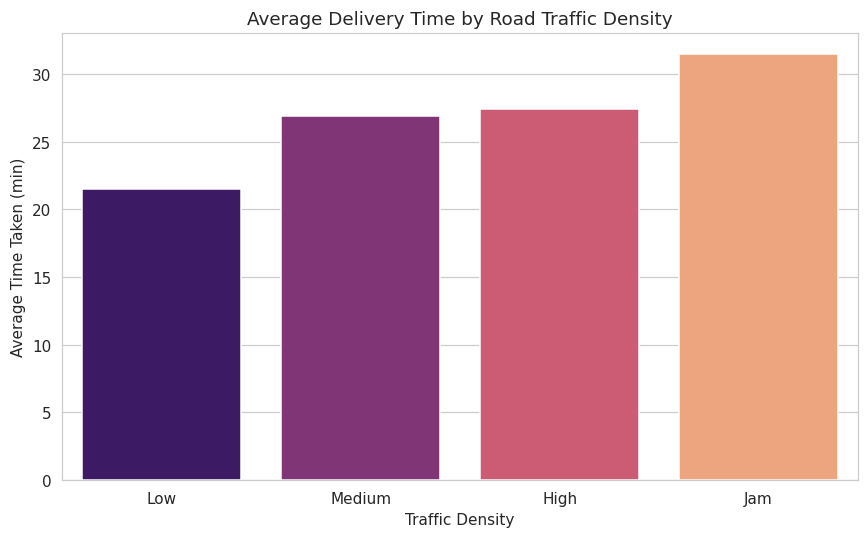

In [28]:
traffic_time = df.groupby("Road_traffic_density")["Time_taken (min)"].mean().sort_values()
plt.figure(figsize=(8, 5))
sns.barplot(x=traffic_time.index, y=traffic_time.values, hue=traffic_time.index,
            palette="magma", legend=False)
plt.title("Average Delivery Time by Road Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Average Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/2_traffic_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()


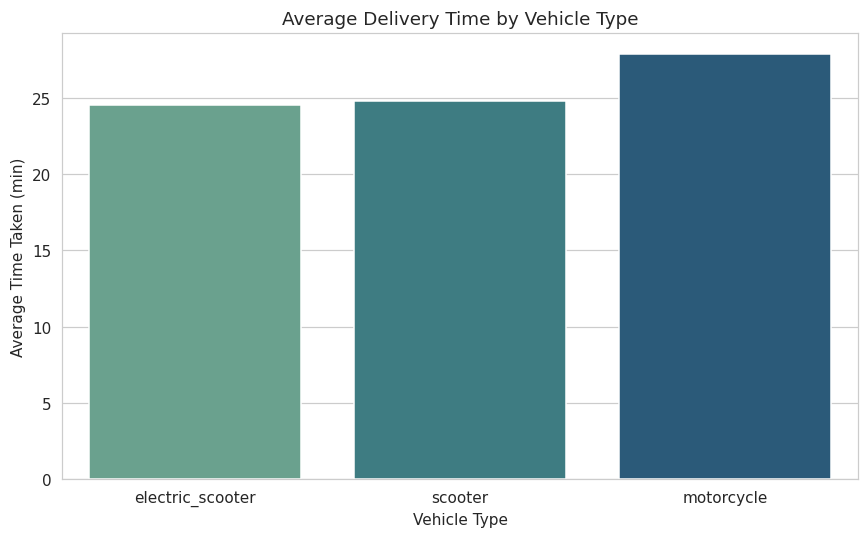

In [29]:
vehicle_time = df.groupby("Type_of_vehicle")["Time_taken (min)"].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=vehicle_time.index, y=vehicle_time.values, hue=vehicle_time.index,
            palette="crest", legend=False)
plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/3_vehicle_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

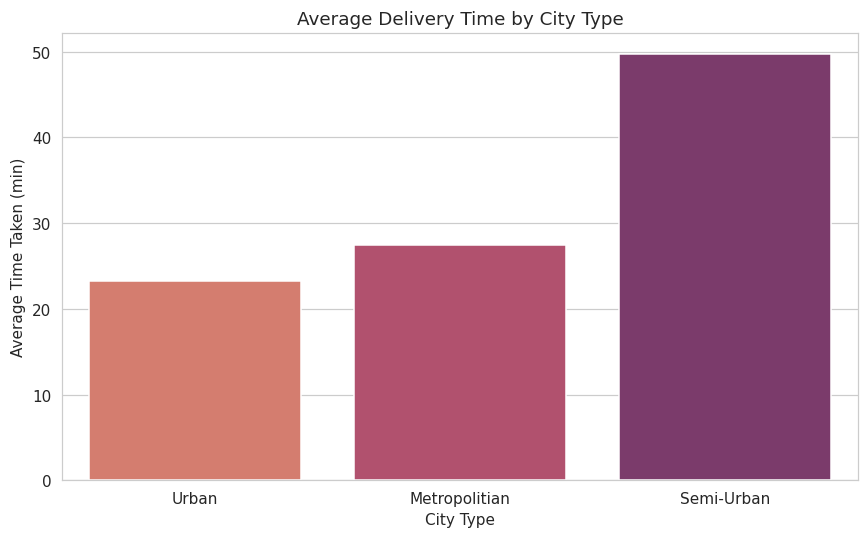

In [30]:
city_time = df.groupby("City")["Time_taken (min)"].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=city_time.index, y=city_time.values, hue=city_time.index,
            palette="flare", legend=False)
plt.title("Average Delivery Time by City Type")
plt.xlabel("City Type")
plt.ylabel("Average Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/4_city_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()


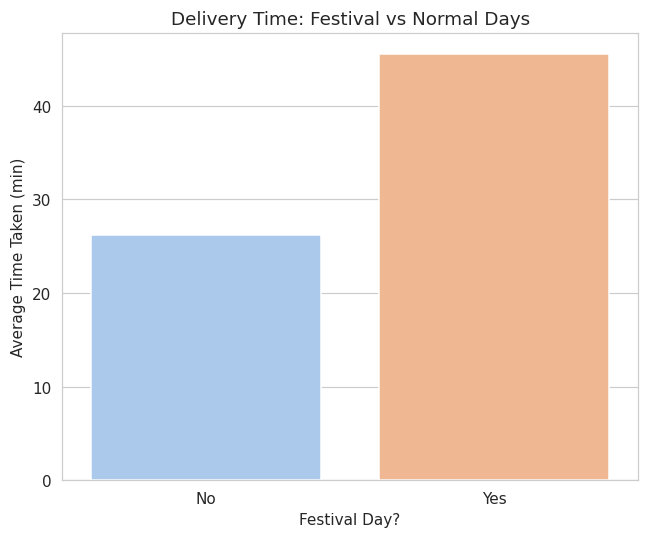

In [31]:
festival_time = df.groupby("Festival")["Time_taken (min)"].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=festival_time.index, y=festival_time.values, hue=festival_time.index,
            palette="pastel", legend=False)
plt.title("Delivery Time: Festival vs Normal Days")
plt.xlabel("Festival Day?")
plt.ylabel("Average Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/5_festival_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

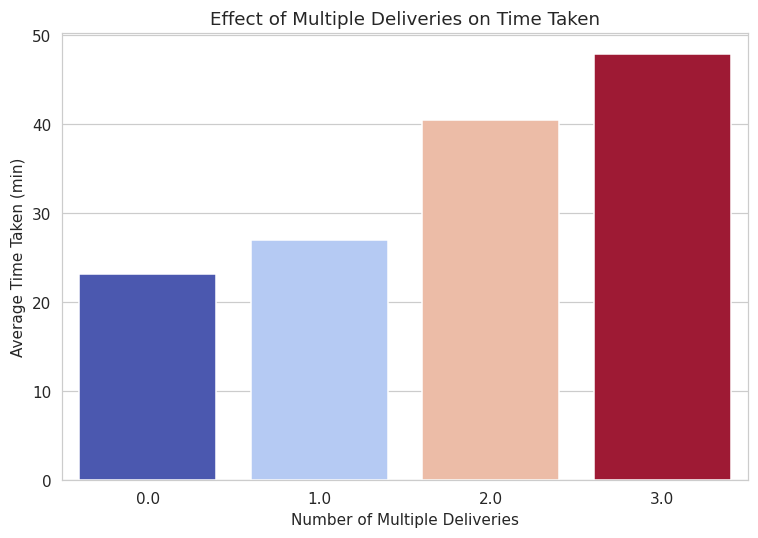

In [32]:
multi_time = df.groupby("multiple_deliveries")["Time_taken (min)"].mean()

plt.figure(figsize=(7, 5))
sns.barplot(x=multi_time.index, y=multi_time.values, hue=multi_time.index,
            palette="coolwarm", legend=False)
plt.title("Effect of Multiple Deliveries on Time Taken")
plt.xlabel("Number of Multiple Deliveries")
plt.ylabel("Average Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/6_multideliveries_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

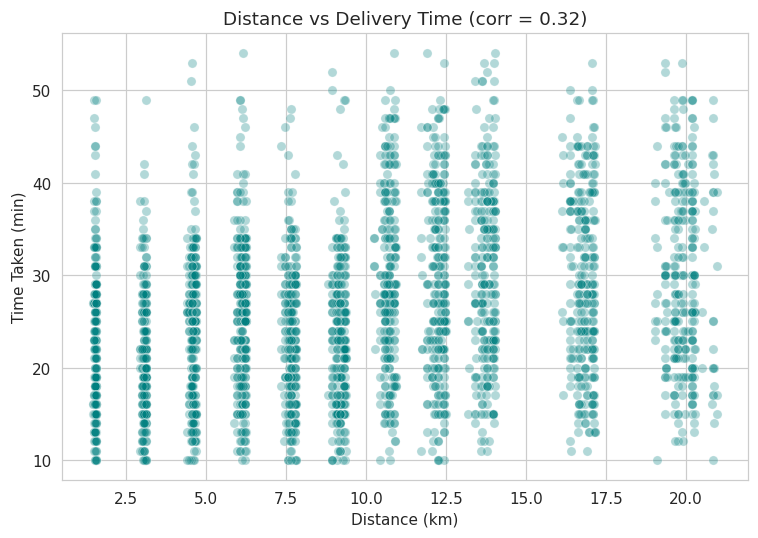

In [33]:
correlation = df["distance_km"].corr(df["Time_taken (min)"])

plt.figure(figsize=(7, 5))
sns.scatterplot(x="distance_km", y="Time_taken (min)", data=df.sample(3000, random_state=1),
                 alpha=0.3, color="teal")
plt.title(f"Distance vs Delivery Time (corr = {correlation:.2f})")
plt.xlabel("Distance (km)")
plt.ylabel("Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/7_distance_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

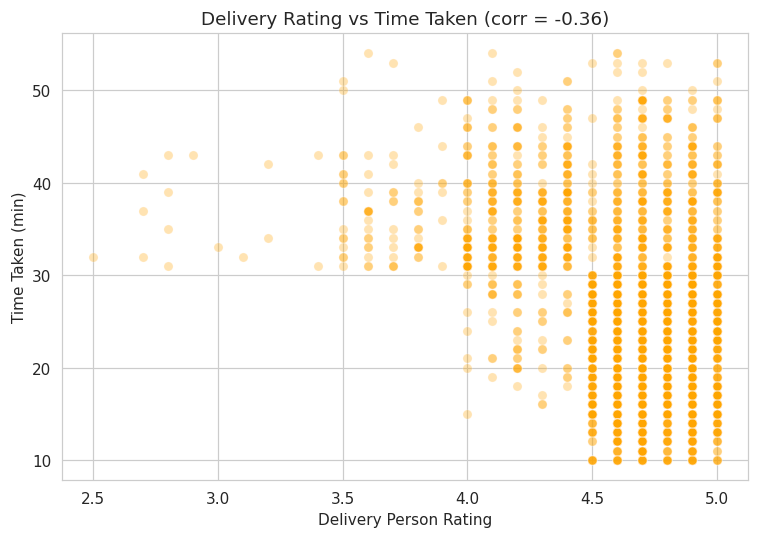

In [34]:
rating_corr = df["Delivery_person_Ratings"].corr(df["Time_taken (min)"])

plt.figure(figsize=(7, 5))
sns.scatterplot(x="Delivery_person_Ratings", y="Time_taken (min)",
                 data=df.sample(3000, random_state=1), alpha=0.3, color="orange")
plt.title(f"Delivery Rating vs Time Taken (corr = {rating_corr:.2f})")
plt.xlabel("Delivery Person Rating")
plt.ylabel("Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/8_rating_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
vehcond_time = df.groupby("Vehicle_condition")["Time_taken (min)"].mean()
print("\nAvg delivery time by vehicle condition (0=worst, higher=better):\n", vehcond_time)


Avg delivery time by vehicle condition (0=worst, higher=better):
 Vehicle_condition
0    30.273796
1    24.670609
2    24.751760
Name: Time_taken (min), dtype: float64


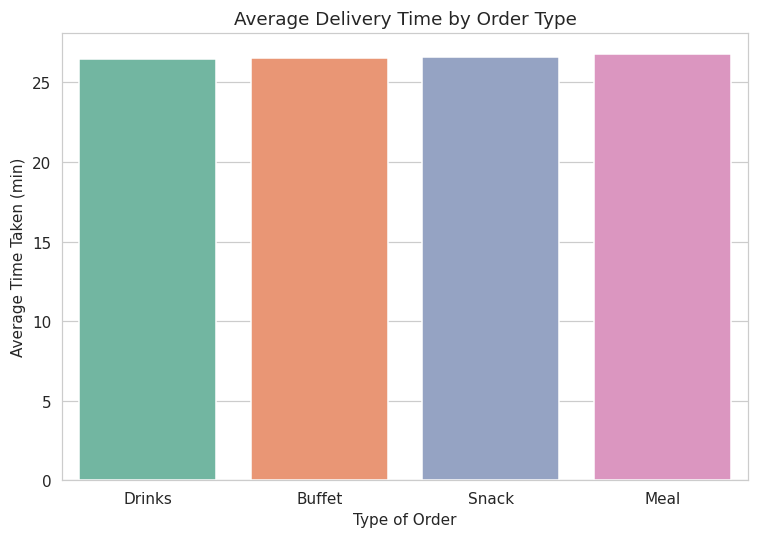

In [36]:
ordertype_time = df.groupby("Type_of_order")["Time_taken (min)"].mean().sort_values()

plt.figure(figsize=(7, 5))
sns.barplot(x=ordertype_time.index, y=ordertype_time.values, hue=ordertype_time.index,
            palette="Set2", legend=False)
plt.title("Average Delivery Time by Order Type")
plt.xlabel("Type of Order")
plt.ylabel("Average Time Taken (min)")
plt.tight_layout()
plt.savefig("outputs/9_ordertype_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

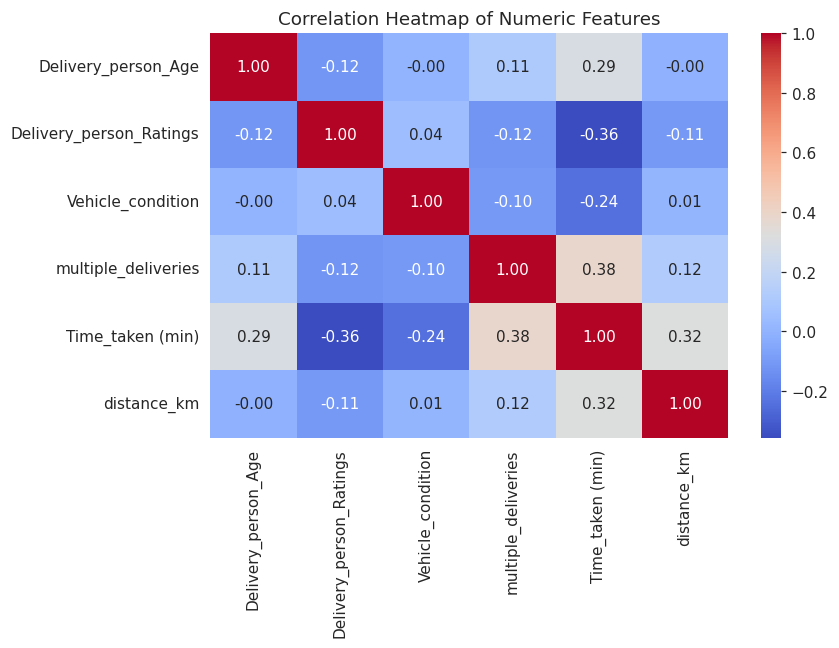

In [37]:
numeric_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
                "multiple_deliveries", "Time_taken (min)", "distance_km"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("outputs/10_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# F. Business Insights


In [38]:
traffic_time = df.groupby("Road_traffic_density")["Time_taken (min)"].mean().sort_values(ascending=False)
print("Insight 1 - Traffic:\n", traffic_time)

Insight 1 - Traffic:
 Road_traffic_density
Jam       31.440229
High      27.413489
Medium    26.925701
Low       21.496461
Name: Time_taken (min), dtype: float64


In [39]:
festival_time = df.groupby("Festival")["Time_taken (min)"].mean()
print("\nInsight 2 - Festival:\n", festival_time)



Insight 2 - Festival:
 Festival
No     26.193688
Yes    45.468112
Name: Time_taken (min), dtype: float64


In [40]:
city_time = df.groupby("City")["Time_taken (min)"].mean().sort_values(ascending=False)
print("\nInsight 3 - City:\n", city_time)


Insight 3 - City:
 City
Semi-Urban       49.691781
Metropolitian    27.445199
Urban            23.243339
Name: Time_taken (min), dtype: float64


In [41]:
vehicle_time = df.groupby("Type_of_vehicle")["Time_taken (min)"].mean().sort_values()
print("Insight 4 - Vehicle Type:\n", vehicle_time)


Insight 4 - Vehicle Type:
 Type_of_vehicle
electric_scooter    24.560724
scooter             24.805818
motorcycle          27.854677
Name: Time_taken (min), dtype: float64


In [42]:
multi_time = df.groupby("multiple_deliveries")["Time_taken (min)"].mean()
print("\nInsight 5 - Multiple Deliveries:\n", multi_time)


Insight 5 - Multiple Deliveries:
 multiple_deliveries
0.0    23.155446
1.0    26.995952
2.0    40.489338
3.0    47.846645
Name: Time_taken (min), dtype: float64


In [43]:
rating_corr = df["Delivery_person_Ratings"].corr(df["Time_taken (min)"])
print("\nInsight 6 - Rating correlation:", round(rating_corr, 2))


Insight 6 - Rating correlation: -0.36


In [44]:
vehcond_time = df.groupby("Vehicle_condition")["Time_taken (min)"].mean()
print("\nInsight 7 - Vehicle Condition:\n", vehcond_time)


Insight 7 - Vehicle Condition:
 Vehicle_condition
0    30.273796
1    24.670609
2    24.751760
Name: Time_taken (min), dtype: float64


In [45]:
combo_time = df.groupby(["Weather_conditions", "Road_traffic_density"])["Time_taken (min)"].mean().sort_values(ascending=False)
print("\nInsight 8 - Worst combo:\n", combo_time.head(3))


Insight 8 - Worst combo:
 Weather_conditions  Road_traffic_density
Fog                 Jam                     36.889454
Cloudy              Jam                     36.708173
Windy               Jam                     30.396925
Name: Time_taken (min), dtype: float64


# G. AI-Powered Explanation 

In [46]:
!pip install groq -q

from kaggle_secrets import UserSecretsClient
from groq import Groq

user_secrets = UserSecretsClient()
GROQ_API_KEY = user_secrets.get_secret("GROQ_API_KEY_OF_FOOD _DELIVERY_DATA")
client = Groq(api_key=GROQ_API_KEY)

analysis_summary = f"""
Total deliveries: {total_deliveries}
Average delivery time: {avg_time:.2f} minutes
Traffic impact: Jam = {traffic_time.max():.2f} min, Low traffic = {traffic_time.min():.2f} min
Distance impact: Correlation between distance and time = {correlation:.2f}
Weather+Traffic worst combo: {combo_time.index[0]} = {combo_time.iloc[0]:.2f} min
Festival impact: Normal days = {festival_time['No']:.2f} min, Festival days = {festival_time['Yes']:.2f} min
Vehicle type: Fastest = {vehicle_time.idxmin()} ({vehicle_time.min():.2f} min), Slowest = {vehicle_time.idxmax()} ({vehicle_time.max():.2f} min)
Rating correlation with time: {rating_corr:.2f}
"""

response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {
            "role": "system",
            "content": "You are a business data analyst. Explain the given delivery analytics results in simple, clear business language. Focus on what actions the company should take."
        },
        {
            "role": "user",
            "content": f"Here are our calculated food delivery analysis results:\n{analysis_summary}\n\nExplain these findings in 3-4 short paragraphs for a business presentation."
        }
    ],
    temperature=0.5,
    max_tokens=500
)

ai_explanation = response.choices[0].message.content
print(ai_explanation)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 1.4 MB/s eta 0:00:00
**Overall performance** – In the last period we completed 38,964 orders with an average door‑to‑door time of **26.6 minutes**. That is close to our target of 30 minutes, but there is still room to tighten the margin, especially on days when external factors push the time well above the average.

**What slows us down** – Traffic is the biggest single driver. When a jam occurs the delivery clock jumps to **31.4 minutes**, versus **21.5 minutes** in light‑traffic conditions. Bad weather compounds the problem: the worst‑case combo of **fog + jam** pushes the average to **36.9 minutes**. Festivals also have a dramatic effect – delivery time spikes from **26.2 minutes** on normal days to **45.5 minutes** on festival days. Distance matters, but only modestly (correlation 0.32), so we should focus more on the “when” than the “how far”.

**What works best** – Vehicles matter. Orders delivered by **electric scooters*